<a href="https://colab.research.google.com/github/Ifaz2611/ML-Projects-By_Ifaz/blob/main/Asteroid_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Machine Learning on the Kaggle Asteroid Dataset***

 ### Objective

This notebook builds a complete binary classification model that predicts whether an asteroid is potentially hazardous (pha = Y) or not potentially hazardous (pha = N). The workflow is designed for Google Colab and includes data upload, cleaning, exploratory analysis, preprocessing, model comparison, evaluation, interpretation, saving, and prediction on new asteroid records.

```
Important assumption: Because only the column names were provided, this notebook assumes that your CSV contains a column named pha with values such as Y and N. If you want to predict a different column, change TARGET_COLUMN in the configuration cell and adjust the target-conversion section.
```

The columns id, spkid, full_name, pdes, name, prefix, orbit_id, epoch_cal, and tp_cal are treated as identifiers or text/date fields and are excluded from the initial model. The target column pha is also excluded from the input features to prevent target leakage. The categorical fields neo, equinox, and class are retained as model inputs when they are present.

---



## Cell 1 — Install or upgrade the required packages

Run this cell first. Colab usually already includes these libraries, but the command makes the environment reproducible.

---

In [1]:
!pip install --upgrade numpy scipy scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 99.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found exist

## Cell 2 — Import libraries and define configuration

In [1]:
import os
import glob
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TARGET_COLUMN = "pha"
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", context="notebook")

print("Libraries imported successfully.")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

Libraries imported successfully.
numpy: 2.5.2
pandas: 2.2.2


## Cell 3 — Upload your Kaggle CSV file

Download the dataset from Kaggle to your computer, then run this cell and select the CSV file. If your file is already in the Colab runtime, you can skip this cell and set CSV_PATH manually in the next cell

---

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/Astreroid_dataset.csv'

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Make sure the file is in your main Drive folder and the spelling is exact!")

print(f"Successfully loaded: {CSV_PATH}")

Mounted at /content/drive
Successfully loaded: /content/drive/MyDrive/Astreroid_dataset.csv


## Cell 4 — Load the dataset
---

In [3]:
if "CSV_PATH" not in globals():
    csv_candidates = glob.glob("/content/*.csv") + glob.glob("/home/ubuntu/*.csv")
    if len(csv_candidates) == 0:
        raise FileNotFoundError("No CSV file was found. Upload your Kaggle CSV first.")
    CSV_PATH = csv_candidates[0]

df = pd.read_csv(CSV_PATH)
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9_]+", "_", regex=True)
      .str.strip("_")
)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("Columns:")
print(df.columns.tolist())
df.head()

Dataset shape: 958,524 rows x 45 columns
Columns:
['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'h', 'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


,id,spkid,full_name,pdes,name,prefix,neo,pha,h,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,59000,20200531.0,J2000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,58600,20190427.0,J2000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,59000,20200531.0,J2000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


## Cell 5 — Inspect data types, missing values, duplicates, and target balance

---

In [4]:
if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"The target column '{TARGET_COLUMN}' was not found. Available columns are: {df.columns.tolist()}"
    )

inspection = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})

print("Data types and missingness:")
display(inspection.sort_values("missing_percent", ascending=False))

print(f"Duplicate rows: {df.duplicated().sum():,}")
print("Raw target values:")
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame("count"))

Data types and missingness:


,dtype,missing_count,missing_percent,unique_values
prefix,object,958506,100.00,1
name,object,936460,97.70,22064
albedo,float64,823421,85.91,1057
diameter_sigma,float64,822443,85.80,3054
diameter,float64,822315,85.79,16591
pha,object,19921,2.08,2
sigma_per,float64,19926,2.08,282687
sigma_ad,float64,19926,2.08,269241
sigma_n,float64,19922,2.08,251750
sigma_i,float64,19922,2.08,215741


Duplicate rows: 0
Raw target values:


,count
pha,
N,936537
NaN,19921
Y,2066


## Cell 6 — Clean and convert the target variable

This cell converts common binary target representations into numeric labels:

• 1 means potentially hazardous asteroid.

• 0 means not potentially hazardous asteroid.

---



Rows available for modeling: 938,603
Clean target distribution:


,count
target,
Not PHA,936537
PHA,2066


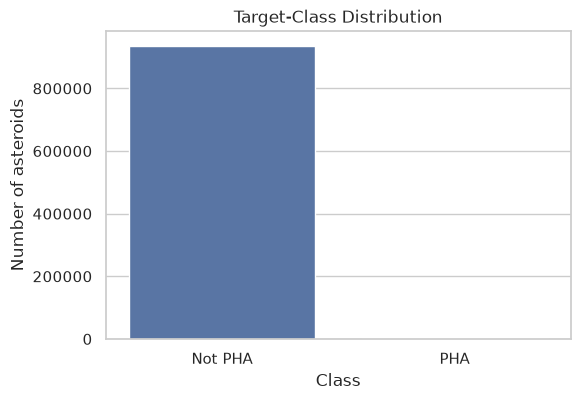

In [5]:
def normalize_binary_target(series):
    """Convert common binary text/numeric values to 1 and 0."""
    result = pd.Series(np.nan, index=series.index, dtype="float64")
    text = series.astype("string").str.strip().str.upper()

    positive_values = {"Y", "YES", "TRUE", "T", "1", "1.0", "POSITIVE"}
    negative_values = {"N", "NO", "FALSE", "F", "0", "0.0", "NEGATIVE"}

    result[text.isin(positive_values)] = 1
    result[text.isin(negative_values)] = 0
    numeric = pd.to_numeric(series, errors="coerce")
    result[result.isna() & numeric.eq(1)] = 1
    result[result.isna() & numeric.eq(0)] = 0

    return result
df = df.drop_duplicates().reset_index(drop=True)

df["target"] = normalize_binary_target(df[TARGET_COLUMN])

unknown_target_values = df.loc[df["target"].isna(), TARGET_COLUMN].dropna().unique().tolist()
if unknown_target_values:
    print("Warning: these target values could not be converted and will be removed:", unknown_target_values)

df = df.dropna(subset=["target"]).copy()
df["target"] = df["target"].astype(int)

y = df["target"]

if y.nunique() != 2:
    raise ValueError(
        f"The target must contain exactly two classes after cleaning. Found: {sorted(y.unique().tolist())}"
    )

print(f"Rows available for modeling: {len(df):,}")
print("Clean target distribution:")
display(y.value_counts().rename(index={0: "Not PHA", 1: "PHA"}).to_frame("count"))

plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: "Not PHA", 1: "PHA"}), order=["Not PHA", "PHA"])
plt.title("Target-Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of asteroids")
plt.show()

## Cell 7 — Select useful features and remove identifier leakage

Identifiers generally allow a model to memorize rows instead of learning meaningful relationships. They are therefore excluded. The target pha and the temporary numeric target target are also excluded.

---


In [6]:
EXCLUDED_COLUMNS = {
    TARGET_COLUMN,
    "target",
    "id",
    "spkid",
    "full_name",
    "pdes",
    "name",
    "prefix",
    "orbit_id",
    "epoch_cal",
    "tp_cal",
}

available_excluded = sorted(EXCLUDED_COLUMNS.intersection(df.columns))
feature_df = df.drop(columns=available_excluded, errors="ignore").copy()

KNOWN_CATEGORICAL_COLUMNS = ["neo", "equinox", "class"]
categorical_columns = [c for c in KNOWN_CATEGORICAL_COLUMNS if c in feature_df.columns]
for column in feature_df.columns:
    if column not in categorical_columns:
        feature_df[column] = pd.to_numeric(feature_df[column], errors="coerce")
    else:
        feature_df[column] = feature_df[column].astype("string").replace(pd.NA, np.nan)

all_missing_columns = [c for c in feature_df.columns if feature_df[c].isna().all()]
constant_columns = [c for c in feature_df.columns if feature_df[c].nunique(dropna=True) <= 1]
columns_to_drop = sorted(set(all_missing_columns + constant_columns))
feature_df = feature_df.drop(columns=columns_to_drop, errors="ignore")

categorical_columns = [c for c in categorical_columns if c in feature_df.columns]
numeric_columns = [c for c in feature_df.columns if c not in categorical_columns]

for column in numeric_columns:
    if column in feature_df.columns:
        feature_df[column] = feature_df[column].astype(float)

if len(feature_df.columns) == 0:
    raise ValueError("No usable feature columns remain after cleaning.")

print("Excluded columns:", available_excluded)
print("Dropped all-missing or constant columns:", columns_to_drop)
print("Categorical features:", categorical_columns)
print("Numeric features:", numeric_columns)
print(f"Total model features before one-hot encoding: {feature_df.shape[1]}")

display(feature_df.head())

Excluded columns: ['epoch_cal', 'full_name', 'id', 'name', 'orbit_id', 'pdes', 'pha', 'prefix', 'spkid', 'target', 'tp_cal']
Dropped all-missing or constant columns: ['equinox']
Categorical features: ['neo', 'class']
Numeric features: ['h', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']
Total model features before one-hot encoding: 34


,neo,h,diameter,albedo,diameter_sigma,epoch,epoch_mjd,e,a,q,i,om,w,ma,ad,n,tp,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,3.40,939.400,0.0900,0.200,2458600.5,58600.0,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,4.20,545.000,0.1010,18.000,2459000.5,59000.0,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,5.33,246.596,0.2140,10.594,2459000.5,59000.0,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,3.00,525.400,0.4228,0.200,2458600.5,58600.0,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,6.90,106.699,0.2740,3.140,2459000.5,59000.0,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


## Cell 8 — Explore numeric features and correlations

,count,mean,std,min,25%,50%,75%,max
h,932341.0,1.688997e+01,1.801386e+00,-1.100000e+00,1.600000e+01,1.690000e+01,1.770000e+01,3.320000e+01
diameter,136209.0,5.506429e+00,9.425164e+00,2.500000e-03,2.780000e+00,3.972000e+00,5.765000e+00,9.394000e+02
albedo,135103.0,1.306272e-01,1.103228e-01,1.000000e-03,5.300000e-02,7.900000e-02,1.900000e-01,1.000000e+00
diameter_sigma,136081.0,4.791844e-01,7.828952e-01,5.000000e-04,1.800000e-01,3.320000e-01,6.200000e-01,1.400000e+02
epoch,938603.0,2.458871e+06,7.055064e+02,2.425052e+06,2.459000e+06,2.459000e+06,2.459000e+06,2.459000e+06
epoch_mjd,938603.0,5.887092e+04,7.055064e+02,2.505100e+04,5.900000e+04,5.900000e+04,5.900000e+04,5.900000e+04
e,938603.0,1.561461e-01,9.300582e-02,0.000000e+00,9.206445e-02,1.448654e-01,2.005979e-01,1.855356e+00
a,938603.0,2.906752e+00,4.013775e+01,-1.470245e+04,2.388114e+00,2.647342e+00,3.002579e+00,3.348890e+04
q,938603.0,2.397725e+00,2.159374e+00,7.051073e-02,1.971656e+00,2.226687e+00,2.579723e+00,8.039882e+01
i,938603.0,9.048065e+00,6.646721e+00,7.744220e-03,4.154593e+00,7.404507e+00,1.239818e+01,1.750829e+02


,missing_percent
albedo,85.605948
diameter_sigma,85.501751
diameter,85.488114
h,0.667162
sigma_ad,0.000533
sigma_per,0.000533
neo,0.000426
per,0.000426
ad,0.000426
ma,0.000107


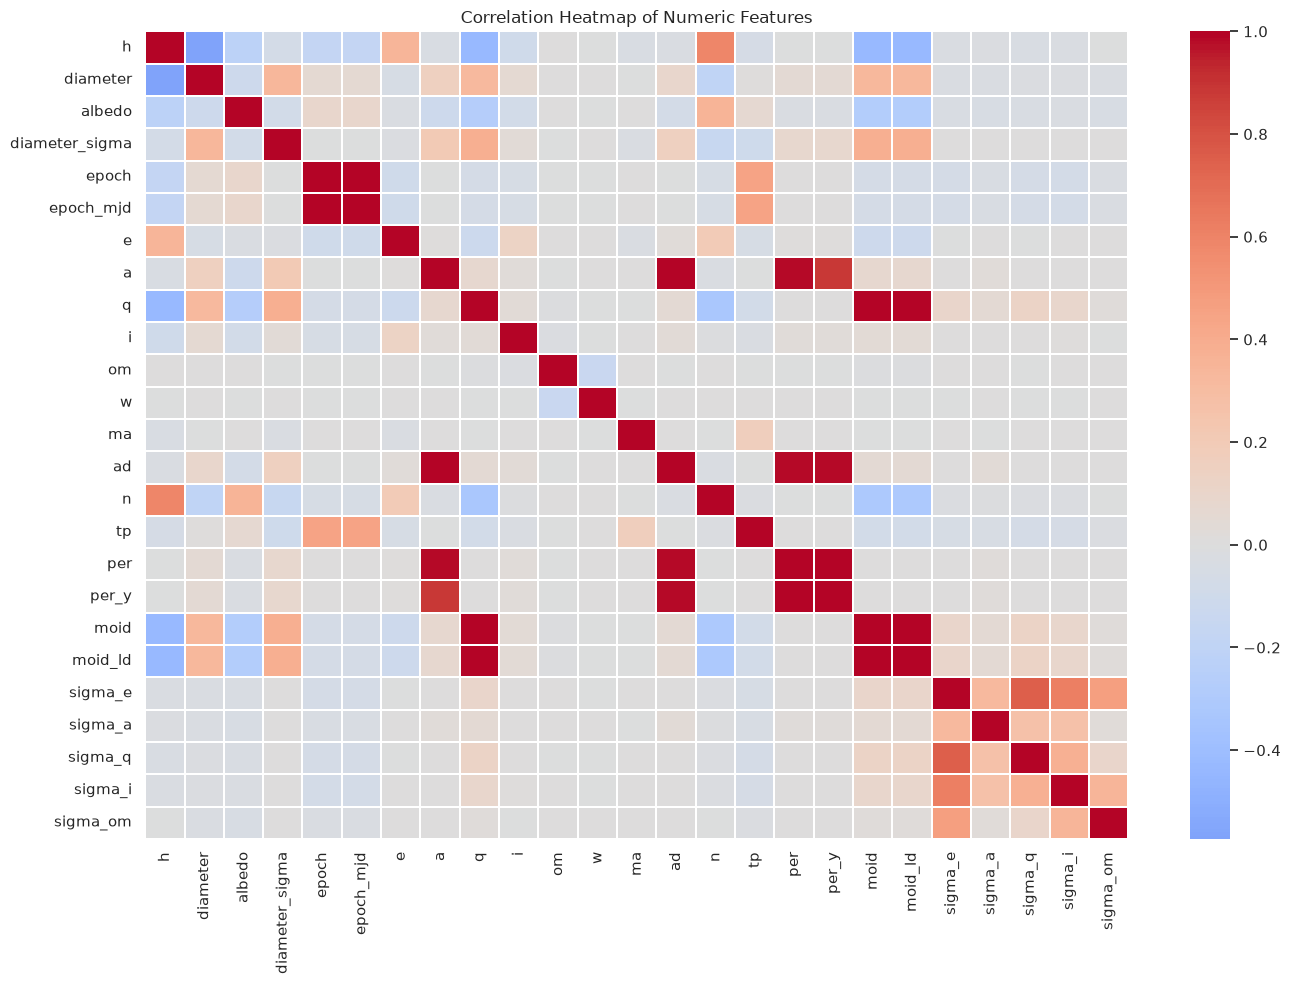

In [7]:
display(feature_df[numeric_columns].describe().T)

missing_features = (
    feature_df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)
display(missing_features.head(20))

heatmap_columns = numeric_columns[:25]
if len(heatmap_columns) >= 2:
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        feature_df[heatmap_columns].corr(numeric_only=True),
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
    )
    plt.title("Correlation Heatmap of Numeric Features")
    plt.tight_layout()
    plt.show()

## Cell 9 — Split data into training and test sets

The test set is kept separate until final evaluation. Stratification preserves approximately the same PHA/non-PHA proportion in both sets, which is important when one class is less common.



In [8]:
X = feature_df.copy()

for col in numeric_columns:
    X[col] = X[col].astype(float)

for col in categorical_columns:
    X[col] = X[col].astype(object).replace({pd.NA: np.nan})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training class proportions:")
print(y_train.value_counts(normalize=True).rename(index={0: "Not PHA", 1: "PHA"}).round(4))
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).rename(index={0: "Not PHA", 1: "PHA"}).round(4))

Training shape: (750882, 34)
Testing shape: (187721, 34)
Training class proportions:
target
Not PHA    0.9978
PHA        0.0022
Name: proportion, dtype: float64
Testing class proportions:
target
Not PHA    0.9978
PHA        0.0022
Name: proportion, dtype: float64


## Cell 10 — Build preprocessing pipelines

The preprocessing is fitted only on the training set inside each complete pipeline. This prevents information from the test set from influencing training.



In [9]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

transformers = []
if numeric_columns:
    transformers.append(("numeric", numeric_pipeline, numeric_columns))
if categorical_columns:
    transformers.append(("categorical", categorical_pipeline, categorical_columns))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## Cell 11 — Define multiple classification models

Two different model families are compared. Logistic regression is a strong, interpretable baseline. Random forest can learn nonlinear relationships and feature interactions. Both models use class balancing because PHA labels may be imbalanced.



In [10]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

print("Models ready:", list(models.keys()))

Models ready: ['Logistic Regression', 'Random Forest']


## Cell 12 — Train the models and compare metrics

For an imbalanced safety-related classification problem, recall, F1 score, ROC-AUC, and average precision are usually more informative than accuracy alone. The code reports all of them.



In [11]:
def evaluate_binary_model(model, X_eval, y_eval, model_name, threshold=0.50):
    """Return useful binary-classification metrics at a chosen probability threshold."""
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "precision": precision_score(y_eval, predictions, zero_division=0),
        "recall": recall_score(y_eval, predictions, zero_division=0),
        "f1": f1_score(y_eval, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probabilities),
        "average_precision": average_precision_score(y_eval, probabilities),
    }
    return metrics, probabilities, predictions

fitted_models = {}
results = []
probabilities_by_model = {}
predictions_by_model = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    metrics, probabilities, predictions = evaluate_binary_model(
        model, X_test, y_test, model_name, threshold=0.50
    )
    results.append(metrics)
    probabilities_by_model[model_name] = probabilities
    predictions_by_model[model_name] = predictions

results_df = pd.DataFrame(results).sort_values(
    by="average_precision", ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))

Training Logistic Regression...
Training Random Forest...


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.50,0.9999,0.9987,0.9537,0.9976,0.9751,1.0000,0.9980
1,Logistic Regression,0.50,0.9933,0.9966,0.2469,1.0000,0.3960,0.9993,0.6844


## Cell 13 — Print detailed reports and confusion matrices

Random Forest
              precision    recall  f1-score   support

     Not PHA       1.00      1.00      1.00    187308
         PHA       0.95      1.00      0.98       413

    accuracy                           1.00    187721
   macro avg       0.98      1.00      0.99    187721
weighted avg       1.00      1.00      1.00    187721



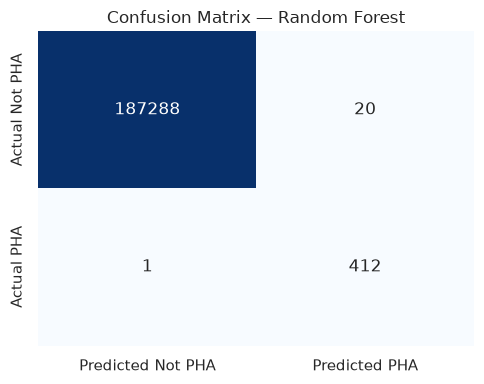

Logistic Regression
              precision    recall  f1-score   support

     Not PHA       1.00      0.99      1.00    187308
         PHA       0.25      1.00      0.40       413

    accuracy                           0.99    187721
   macro avg       0.62      1.00      0.70    187721
weighted avg       1.00      0.99      1.00    187721



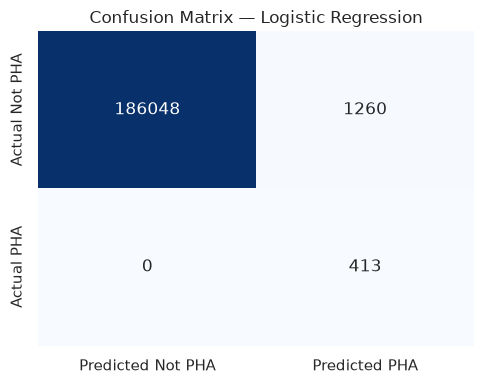

In [12]:
for model_name in results_df["model"]:
    predictions = predictions_by_model[model_name]
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Not PHA", "PHA"],
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Not PHA", "Predicted PHA"],
        yticklabels=["Actual Not PHA", "Actual PHA"],
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

## Cell 14 — Plot ROC and precision-recall curves

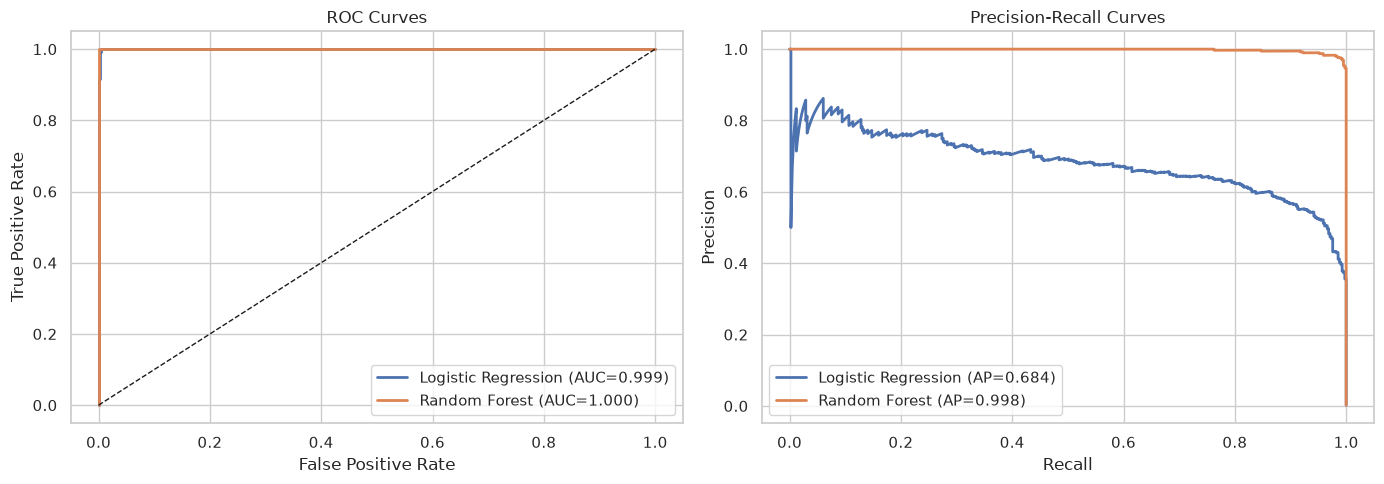

In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model_name, probabilities in probabilities_by_model.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
#------------------------------------------------------------------------------
plt.subplot(1, 2, 2)
for model_name, probabilities in probabilities_by_model.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap_value = average_precision_score(y_test, probabilities)
    plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AP={ap_value:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

plt.tight_layout()
plt.show()

## Cell 15 — Select the best model

This notebook selects the model with the highest average precision on the test set. If your project has a different objective, you can select by recall, F1, ROC-AUC, or another metric instead.



In [14]:
BEST_MODEL_NAME = results_df.loc[0, "model"]
BEST_MODEL = fitted_models[BEST_MODEL_NAME]
BEST_PROBABILITIES = probabilities_by_model[BEST_MODEL_NAME]
BEST_PREDICTIONS = predictions_by_model[BEST_MODEL_NAME]

print(f"Selected model: {BEST_MODEL_NAME}")
print("Selection metric: average precision")
print(f"Average precision: {results_df.loc[0, 'average_precision']:.4f}")

Selected model: Random Forest
Selection metric: average precision
Average precision: 0.9980


## Cell 16 — Tune the classification threshold for higher recall

A probability threshold of 0.50 is not always the best operating point. If missing a potentially hazardous asteroid is more costly than investigating a false alarm, you may prefer a lower threshold. This cell shows the trade-off between precision and recall.



,threshold,precision,recall,f1,balanced_accuracy
0,0.05,0.7897,1.0000,0.8825,0.9997
1,0.10,0.8920,1.0000,0.9429,0.9999
2,0.15,0.9057,1.0000,0.9505,0.9999
3,0.20,0.9178,1.0000,0.9571,0.9999
4,0.25,0.9344,1.0000,0.9661,0.9999
5,0.30,0.9408,1.0000,0.9695,0.9999
6,0.35,0.9451,1.0000,0.9718,0.9999
7,0.40,0.9471,0.9976,0.9717,0.9987
8,0.45,0.9493,0.9976,0.9728,0.9987
9,0.50,0.9537,0.9976,0.9751,0.9987


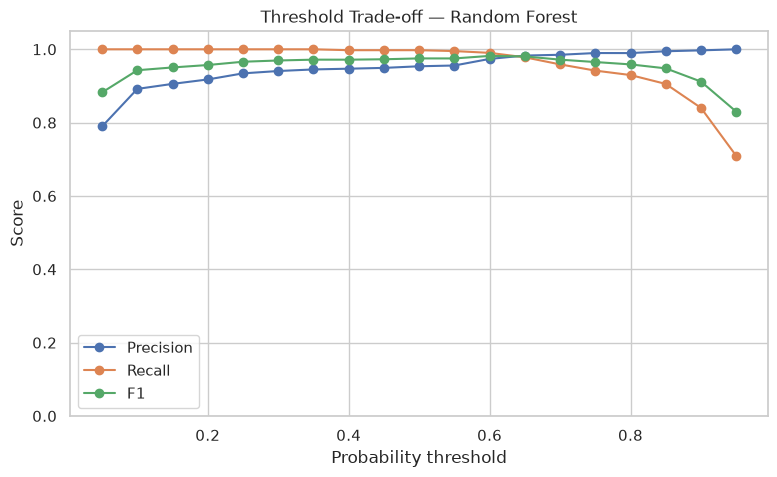

Current deployment threshold: 0.50


In [15]:
threshold_rows = []

for threshold in np.arange(0.05, 1.00, 0.05):
    predictions = (BEST_PROBABILITIES >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.style.format({
    "threshold": "{:.2f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
}))

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.title(f"Threshold Trade-off — {BEST_MODEL_NAME}")
plt.ylim(0, 1.05)
plt.legend()
plt.show()
DEPLOYMENT_THRESHOLD = 0.50
print(f"Current deployment threshold: {DEPLOYMENT_THRESHOLD:.2f}")

## Cell 17 — Optional cross-validation on the training data

Cross-validation gives a more stable estimate of performance than relying on one train/test split. The test set remains untouched in this section.



In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_validate(
    BEST_MODEL,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    },
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame({
    metric.replace("test_", ""): values
    for metric, values in cv_scores.items()
    if metric.startswith("test_")
}).agg(["mean", "std"]).T

display(cv_summary.style.format("{:.4f}"))

,mean,std
accuracy,0.9999,0.0000
balanced_accuracy,0.9939,0.0019
precision,0.9618,0.0118
recall,0.9879,0.0037
f1,0.9747,0.0072
roc_auc,0.9997,0.0007
average_precision,0.9951,0.0015


## Cell 18 — Inspect model feature importance

For a random forest, the transformed features have impurity-based feature importance. For logistic regression, the absolute coefficient magnitude is useful as a simple directional importance measure. This code works with either selected model.



,feature,importance
19,moid_ld,0.172866
18,moid,0.165039
32,neo_N,0.129263
8,q,0.107163
33,neo_Y,0.106315
42,class_MBA,0.071609
35,class_APO,0.057946
0,h,0.044893
6,e,0.043836
7,a,0.022897


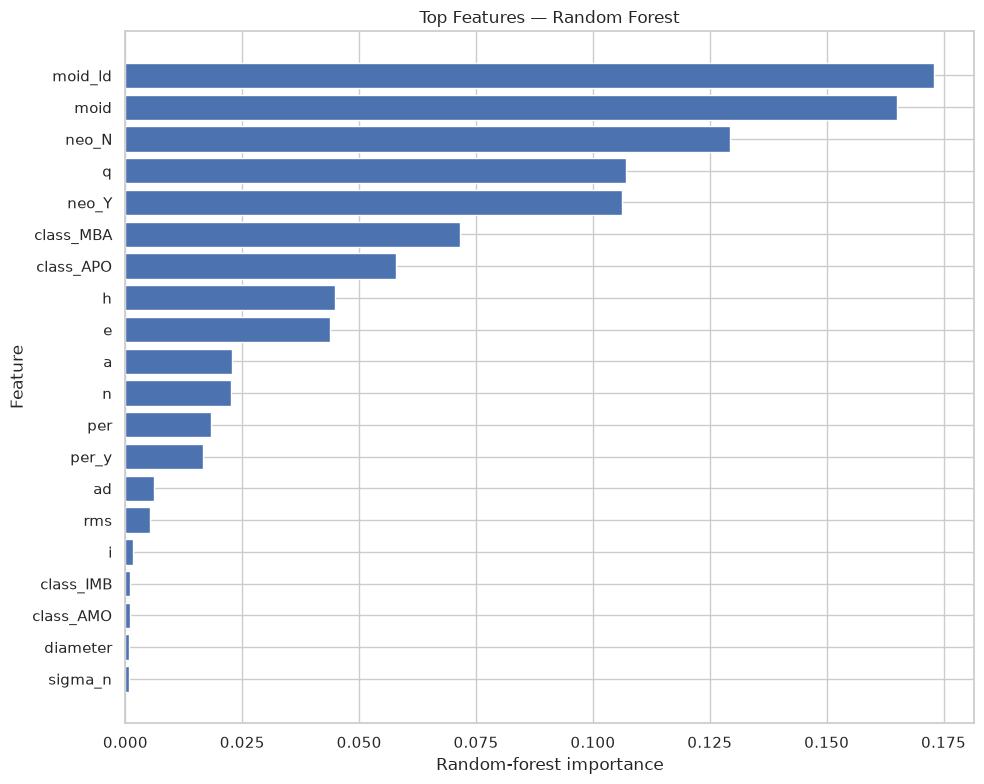

In [17]:
fitted_preprocessor = BEST_MODEL.named_steps["preprocessor"]
fitted_estimator = BEST_MODEL.named_steps["model"]

try:
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = np.array([f"feature_{i}" for i in range(
        fitted_preprocessor.transform(X_train).shape[1]
    )])

if hasattr(fitted_estimator, "feature_importances_"):
    importance_values = fitted_estimator.feature_importances_
    importance_label = "Random-forest importance"
elif hasattr(fitted_estimator, "coef_"):
    importance_values = np.abs(fitted_estimator.coef_[0])
    importance_label = "Absolute logistic-regression coefficient"
else:
    importance_values = None
    importance_label = "Importance"

if importance_values is not None:
    importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importance_values,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(25))

    plt.figure(figsize=(10, 8))
    top_importance = importance_df.head(20).sort_values("importance")
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"Top Features — {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()
else:
    print("The selected estimator does not expose feature importance or coefficients.")

## Cell 19 — Save the trained model and metadata

Saving the complete pipeline preserves the preprocessing steps and model together. The metadata file records the feature schema and threshold used for prediction.



In [18]:
MODEL_PATH = "/content/asteroid_pha_classifier.joblib"
METADATA_PATH = "/content/asteroid_pha_classifier_metadata.joblib"

feature_columns = X.columns.tolist()
metadata = {
    "target_column": TARGET_COLUMN,
    "feature_columns": feature_columns,
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "excluded_columns": available_excluded,
    "deployment_threshold": DEPLOYMENT_THRESHOLD,
    "model_name": BEST_MODEL_NAME,
    "random_state": RANDOM_STATE,
}

joblib.dump(BEST_MODEL, MODEL_PATH)
joblib.dump(metadata, METADATA_PATH)

print("Saved:")
print(MODEL_PATH)
print(METADATA_PATH)

Saved:
/content/asteroid_pha_classifier.joblib
/content/asteroid_pha_classifier_metadata.joblib


Optional: change the task to predict another target

The supplied schema contains several possible targets. The most natural classification target is pha, but you could also predict neo or class. Change the configuration as follows:

| Target | Problem type | Example interpretation |
| --- | --- | --- |
| `pha` | Binary classification | Predict whether the asteroid is potentially hazardous |
| `neo` | Binary classification | Predict whether the asteroid is near-Earth |
| `class` | Multiclass classification | Predict the orbital class |
| `diameter` | Regression | Predict asteroid diameter, after removing rows with missing diameter |
| `albedo` | Regression | Predict albedo, after removing rows with missing albedo |


For neo, set TARGET_COLUMN = "neo" and use the same binary-target conversion if the values are Y and N. For class, use a multiclass target without converting it to binary, use stratify=y only if every class has enough examples, and replace the binary-only metrics with multiclass metrics. For diameter or albedo, use a regression pipeline with RandomForestRegressor or HistGradientBoostingRegressor, and evaluate with MAE, RMSE, and R².

For a first project, the pha classifier is recommended because it gives a clear binary machine-learning objective and allows you to demonstrate class imbalance handling, probability thresholds, confusion matrices, ROC curves, and precision-recall curves.

---

How to interpret the main results

The confusion matrix has four outcomes. A true positive is a PHA correctly identified as PHA; a true negative is a non-PHA correctly identified as non-PHA; a false positive is a non-PHA incorrectly flagged; and a false negative is a PHA that the model missed.

| Metric | Meaning |
| --- | --- |
| Accuracy | Fraction of all predictions that are correct; can be misleading when classes are imbalanced |
| Balanced accuracy | Average recall across the two classes |
| Precision | Of the asteroids flagged as PHA, the fraction that are actually PHA |
| Recall | Of the actual PHA asteroids, the fraction detected by the model |
| F1 score | Harmonic balance between precision and recall |
| ROC-AUC | Ranking quality across probability thresholds |
| Average precision | Precision-recall summary that is often more informative for a rare positive class |

A model is not a scientific or operational replacement for validated astronomical orbit-determination systems. Treat this notebook as an educational machine-learning project, and do not use its predictions alone to make safety-critical decisions.

---

## Common errors and fixes

Error: The target column 'pha' was not found

Check the printed column list. Your file may use a different spelling, such as PHA, potentially_hazardous, or is_pha. Set TARGET_COLUMN to the exact standardized column name after loading the data.

## Error: target contains only one class

The file may be filtered to only PHA or only non-PHA records, or the target values may use an unexpected format. Inspect df[TARGET_COLUMN].value_counts(dropna=False) and add the observed values to positive_values or negative_values in the target-cleaning cell.

## Error: the model predicts almost everything as non-PHA

Inspect the class distribution and the precision-recall curve. Try the class-balanced models already included, increase the training data, and lower DEPLOYMENT_THRESHOLD if your priority is higher recall.

## Error: sparse_output is not recognized

This means the Colab environment has an older scikit-learn version. Replace:



with:

Error: memory usage is too high

Reduce n_estimators in the random forest, remove very high-cardinality categorical columns, or use only the numeric features. Do not include identifiers such as full_name, pdes, or orbit_id as categorical variables.

---


Recommended project conclusion

After running the notebook, report the number of rows, the class distribution, the train/test split, the best model, the selected evaluation metrics, and the chosen probability threshold. Explain whether the model prioritizes precision or recall, show the confusion matrix, and discuss limitations such as missing values, class imbalance, possible label noise, and the fact that this model is intended for learning rather than safety-critical use.

References

[1] Scikit-learn composite estimators and pipelines
[2] Scikit-learn model evaluation documentation
[3] Scikit-learn RandomForestClassifier documentation
[4] Scikit-learn LogisticRegression documentation
[5] Scikit-learn average precision documentation
[6] Scikit-learn precision-recall curve documentation
[1] [2] [3] [4] [5] [6]



